Crack length a= 0.001414213562373095 m


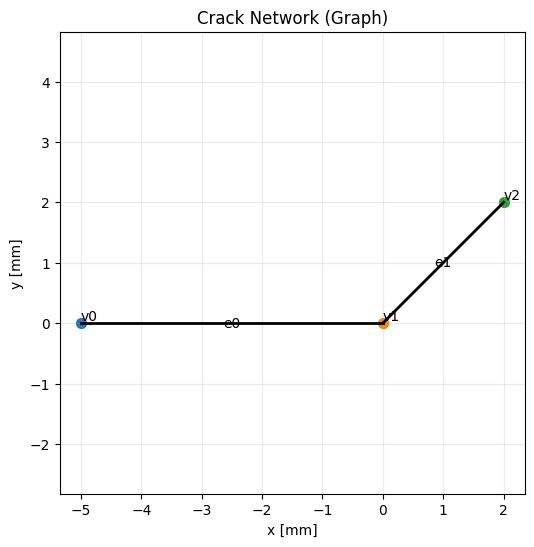

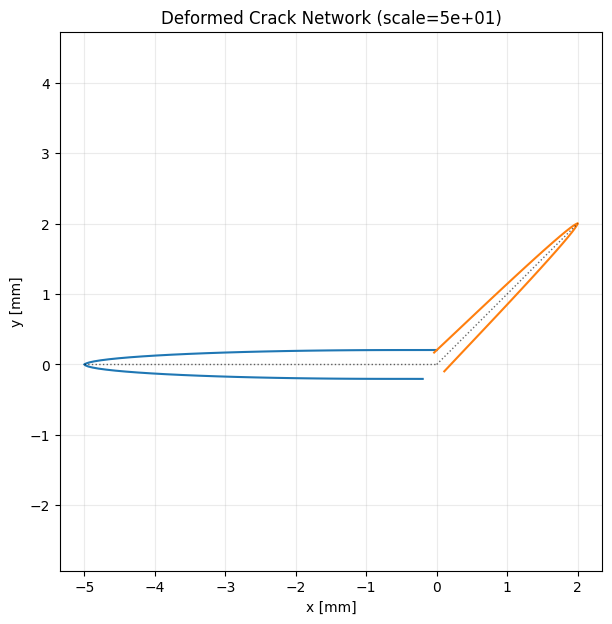

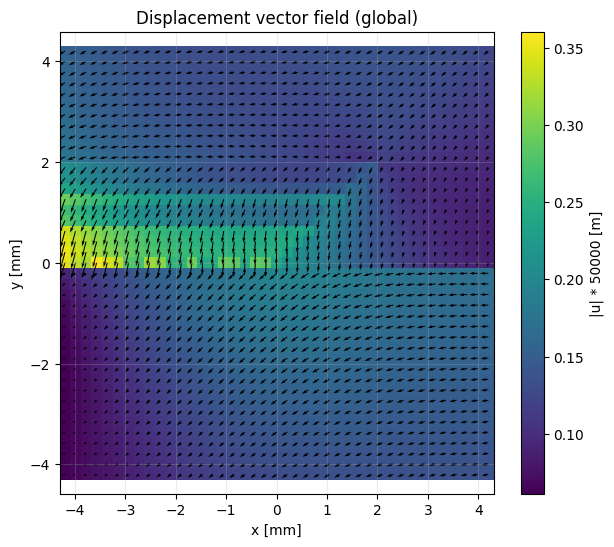

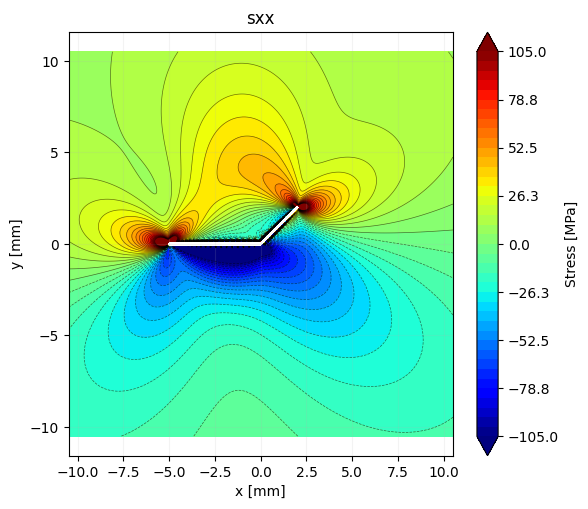

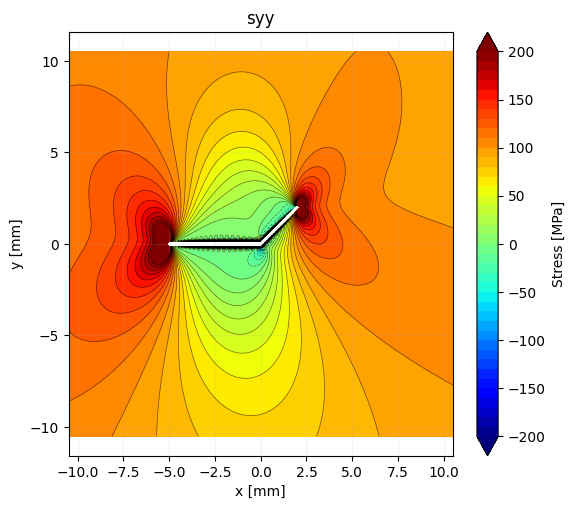

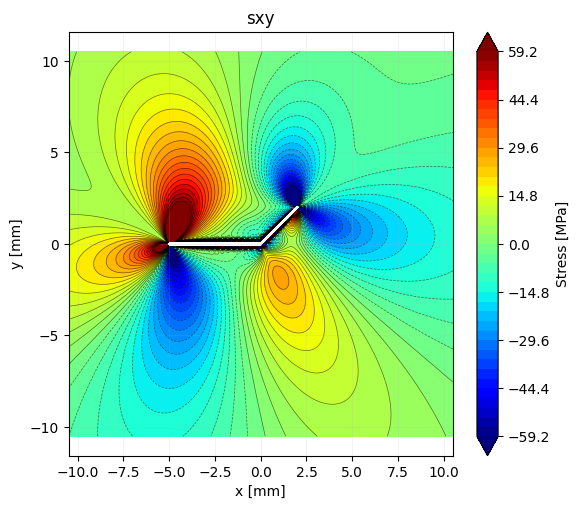

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1
window_panels 2 -> [-2.67158968  0.        ]
window_panels 4 -> [-2.66058377  0.        ]
window_panels 6 -> [-5.14329689  0.        ]
window_panels 8 -> [-11.40679737   0.        ]
window_panels 10 -> [-21.93116543   0.        ]
window_panels 12 -> [-36.90825412   0.        ]
window_panels 14 -> [-56.3908792   0.       ]
window_panels 16 -> [-80.35145861   0.        ]
Ft_window = -5.143296885661442
KI from PK-window = 1.0632003197542745 K_I_theory = 3.3327477170340862
theta (deg) = 0.0
KI, KII = 0.0 0.0
Ft, Fn = -5.143296885661442 0.0


In [1]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   -5.0*mm,  0.0*mm],   # v0 junction
    [1,   0.0*mm,  0.0*mm], # v1 upper-right
    [2,   2.0*mm, 2.0*mm], # v2 lower-right
    # [3,   10.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

a= np.sqrt( (2*mm)**2 + (2*mm)**2 )/2
print("Crack length a=", a, "m")

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


from fracture_utils.Uprocessor.PK import PKProcessor

pk = PKProcessor(res)

# Sensitivity study
for wpanel in [2,4,6,8,10,12,14,16]:
    Fw = pk.F_PK_window(edge_index=0, at="end", exclude_self=True, window_panels=wpanel)
    print("window_panels", wpanel, "->", Fw)

E  = res.calc.material.E
nu = res.calc.material.nu

plane_strain = True  # set True if you want plane strain
Eprime = E/(1-nu**2) if plane_strain else E

F2 = pk.F_PK_window(edge_index=0, at="end", exclude_self=True)
# Local tangential component for straight crack: use extra["ex"] from reconstruct call
_, _, _, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=0, enforce_global_tip_zero=False)
ex = np.asarray(extra["ex"], float).reshape(2,)

Ft = float(np.dot(F2, ex))
KI_PK = np.sqrt(Eprime * abs(Ft))*1e-6  # in MPa√m
K_I_theory =(applied.sigma_yy* np.cos(np.pi/4)**2 +applied.sigma_xx* np.sin(np.pi/4)**2  )* np.sqrt(np.pi * a) *1e-6 # a=5mm
print("Ft_window =", Ft)
print("KI from PK-window =", KI_PK, "K_I_theory =", K_I_theory)

theta_deg, KI, KII, meta = pk.kink_angle_from_PK_window(
    edge_index=0,
    at="end",
    window_panels=6,     # your robust default
    exclude_self=True,
    plane_strain=False,  # or True
    criterion="max_hoop",
)

print("theta (deg) =", theta_deg)
print("KI, KII =", KI, KII)
print("Ft, Fn =", meta["Ft"], meta["Fn"])


In [16]:
import numpy as np

def KI_KII_from_PK_window(res, pk, edge_index, *, at="end", window_panels=6, plane_strain=True):
    # 1) compute PK-window vector in global coords
    F = pk.F_PK_window(edge_index=edge_index, at=at, exclude_self=True, window_panels=window_panels)
    if F is None:
        return None

    # 2) local frame for this straight edge (ex=tangent, ey=normal)
    _, _, _, extra = res.reconstruct_cod_csd_panel_midpoints(edge_index=edge_index, enforce_global_tip_zero=False)
    ex = np.asarray(extra["ex"], float).reshape(2,)
    ey = np.asarray(extra["ey"], float).reshape(2,)

    Ft = float(np.dot(F, ex))   # interpret as J1
    Fn = float(np.dot(F, ey))   # interpret as J2 (possibly up to sign)

    # 3) effective modulus
    E  = float(res.calc.material.E)
    nu = float(res.calc.material.nu)
    Eprime = E/(1.0-nu**2) if plane_strain else E

    # 4) solve for KI, KII using J1/J2 identities
    J1 = Ft
    J2 = Fn

    A = Eprime * J1
    C = -0.5 * Eprime * J2   # uses J2 = -2 KI KII / E' convention

    disc = A*A - 4.0*C*C
    disc = max(disc, 0.0)
    D = np.sqrt(disc)

    KI2  = 0.5*(A + D)
    KII2 = 0.5*(A - D)
    KI2  = max(KI2,  0.0)
    KII2 = max(KII2, 0.0)

    KI  = 1e-6*np.sqrt(KI2)
    KII = 1e-6*np.sign(C) * np.sqrt(KII2)  # KI>=0 by convention

    meta = dict(F_global=np.asarray(F,float), Ft=Ft, Fn=Fn, Eprime=Eprime, J1=J1, J2=J2)
    return KI, KII, meta

for wpanel in [2,4,6,8,10,12,14,16]:
    KI, KII, meta = KI_KII_from_PK_window(res, pk, edge_index=0, at="end", window_panels=wpanel, plane_strain=True)
    print("window_panels", wpanel, "KI =", KI, "KII =", KII)

K_I_theory =(applied.sigma_yy* np.cos(np.pi/4)**2 +applied.sigma_xx* np.sin(np.pi/4)**2  )* np.sqrt(np.pi * a) *1e-6 # a=5mm
K_II_theory = (applied.sigma_yy-applied.sigma_xx)* np.sin(np.pi/4)* np.cos(np.pi/4)* np.sqrt(np.pi * a) *1e-6 # a=5mm

print("KI_theory =", K_I_theory, "KII_theory =", K_II_theory)



window_panels 2 KI = 0.0 KII = 0.0
window_panels 4 KI = 0.0 KII = 0.0
window_panels 6 KI = 0.0 KII = 0.0
window_panels 8 KI = 0.0 KII = 0.0
window_panels 10 KI = 0.0 KII = 0.0
window_panels 12 KI = 0.0 KII = 0.0
window_panels 14 KI = 0.0 KII = 0.0
window_panels 16 KI = 0.0 KII = 0.0
KI_theory = 7.4522504471454525 KII_theory = -7.4522504471454525


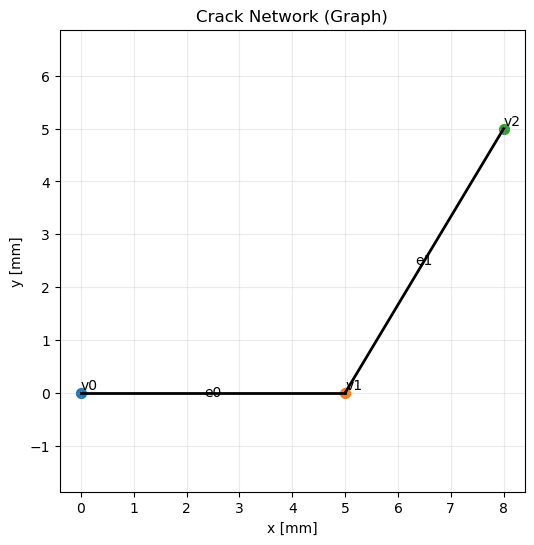

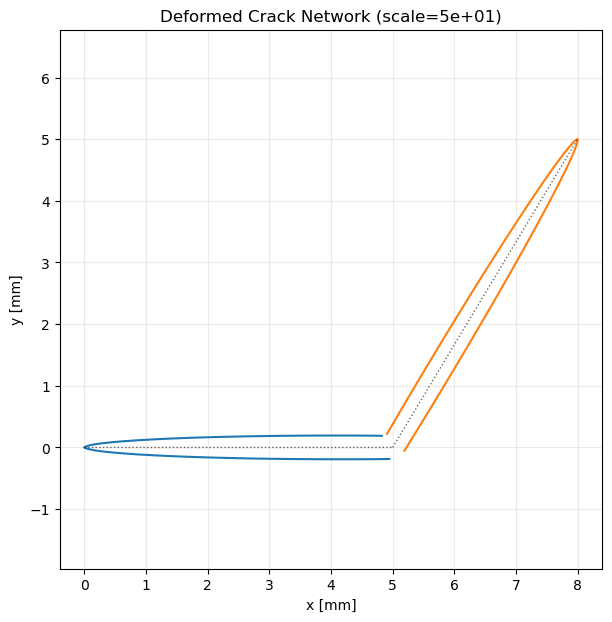

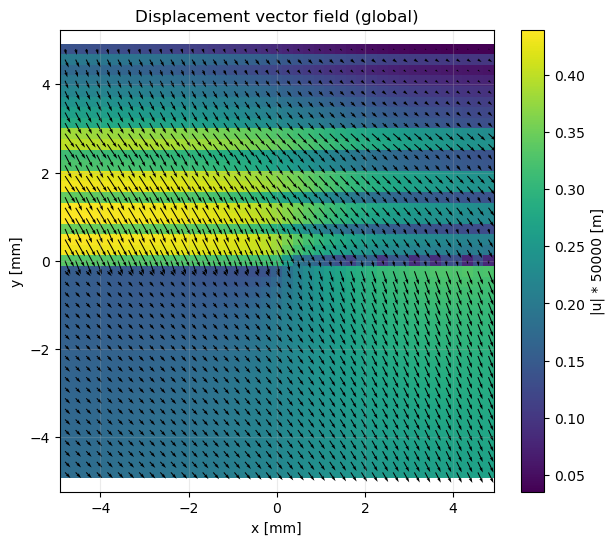

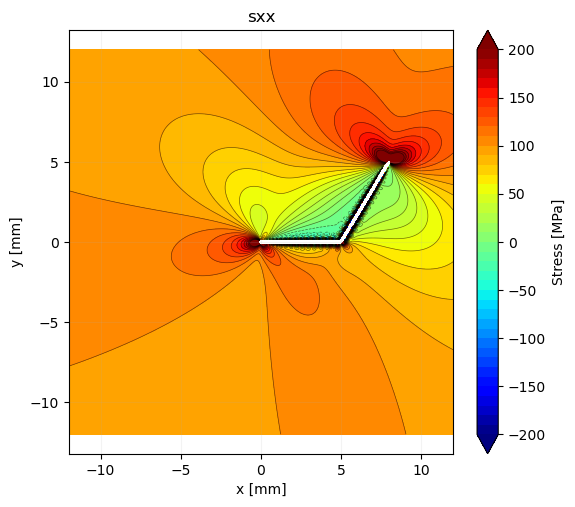

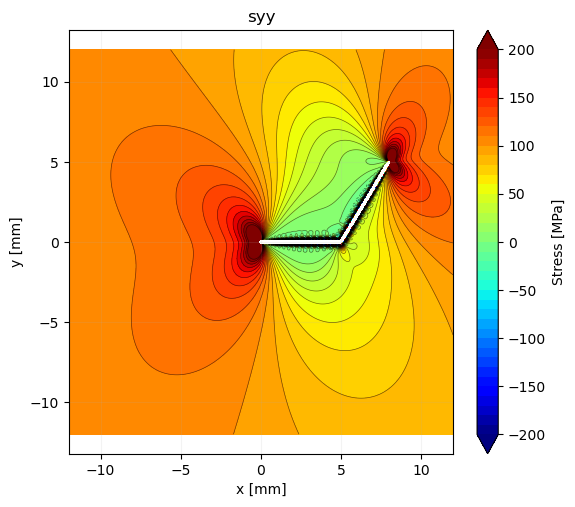

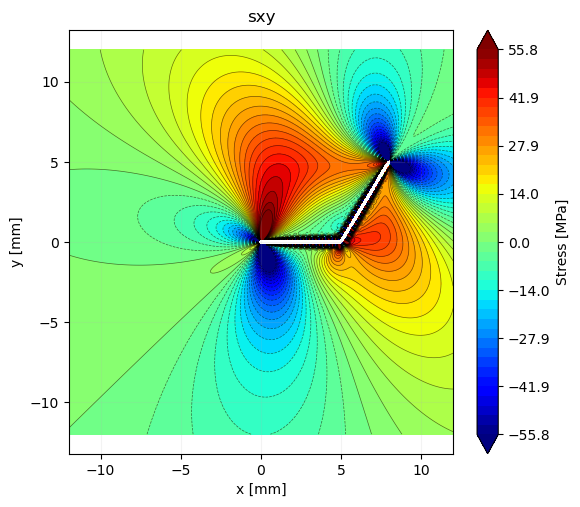

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [1]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 5.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




In [ ]:

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
import numpy as np

# -------------------------
# Build v_inc locally (vertex -> incident (pid, start/end))
# -------------------------
e2p   = sol["parametrized_edge_to_polyline"]
polys = sol["parametrized_polylines"]
solps = sol["polyline_solutions"]

v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    meta = polys[pid]
    v_start = int(meta.get("v_start", meta["path_vertex_ids"][0]))
    v_end   = int(meta.get("v_end",   meta["path_vertex_ids"][-1]))
    v_inc.setdefault(v_start, []).append((pid, "start"))
    v_inc.setdefault(v_end,   []).append((pid, "end"))

def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    tt = (+t[0]) if which == "start" else (-t[-1])
    nrm = np.linalg.norm(tt)
    return tt / nrm if nrm > 0 else np.array([1.0, 0.0])

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)
    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

# -------------------------
# Kink projected closure check (degree-2)
# -------------------------
vk = 1  # kink vertex id

items = v_inc.get(vk, [])
print("\n--- Kink projected closure check ---")
print("vk =", vk, "incident items =", items)

if len(items) != 2:
    print("ERROR: expected exactly 2 incident branches at kink.")
else:
    (pid0, w0), (pid1, w1) = items[0], items[1]
    t0 = outgoing_tangent(pid0, w0)
    t1 = outgoing_tangent(pid1, w1)

    b = t0 + t1
    nb = np.linalg.norm(b)
    if nb <= 0:
        print("ERROR: bisector undefined (t0 ~ -t1).")
    else:
        b /= nb
        n_bis = np.array([-b[1], b[0]])  # bisector normal (CCW)

        B0 = B_of_branch(pid0)
        B1 = B_of_branch(pid1)
        Bsum = B0 + B1

        print(f"pid0={pid0} ({w0})  B0={B0}")
        print(f"pid1={pid1} ({w1})  B1={B1}")
        print("Bsum =", Bsum, " |Bsum| =", float(np.linalg.norm(Bsum)))
        print("n_bis =", n_bis)
        print("n_bis · Bsum =", float(n_bis @ Bsum))



--- Kink projected closure check ---
vk = 1 incident items = [(0, 'start'), (1, 'start')]
pid0=0 (start)  B0=[ 2.00121869e-06 -6.37909680e-06]
pid1=1 (start)  B1=[-2.19283850e-06  7.01197404e-06]
Bsum = [-1.91619809e-07  6.32877236e-07]  |Bsum| = 6.612501395256865e-07
n_bis = [-0.95709203 -0.28978415]
n_bis · Bsum = -5.01602323452156e-20


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Loaded network: 10 vertices, 8 edges
  Node IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


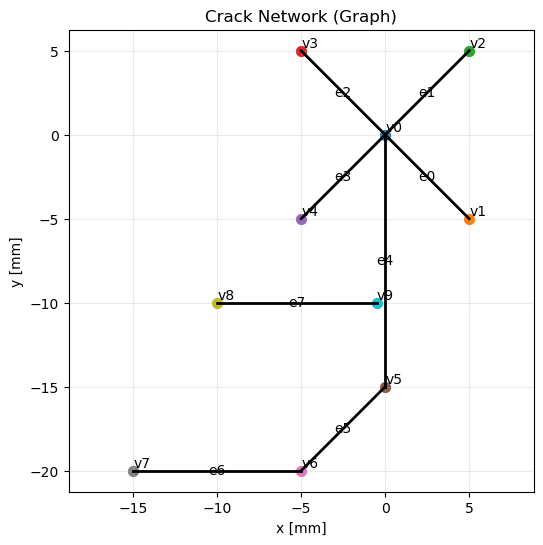

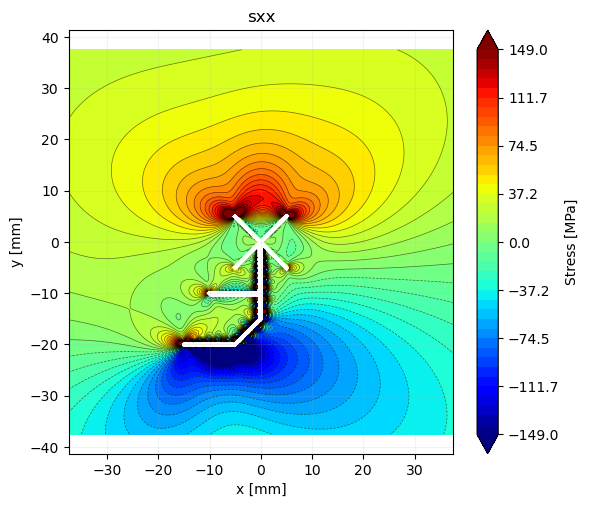

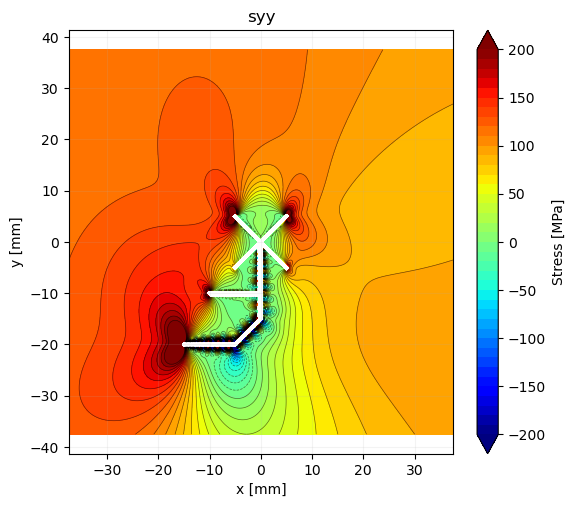

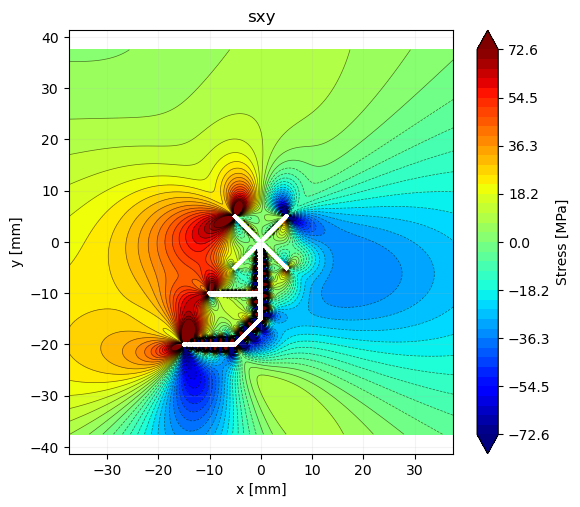

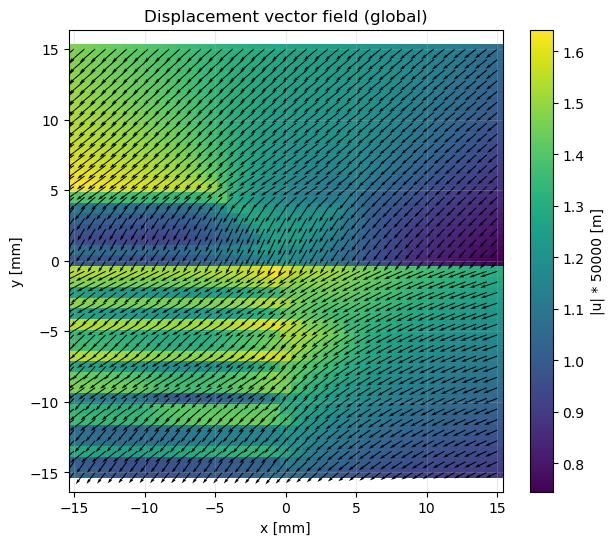

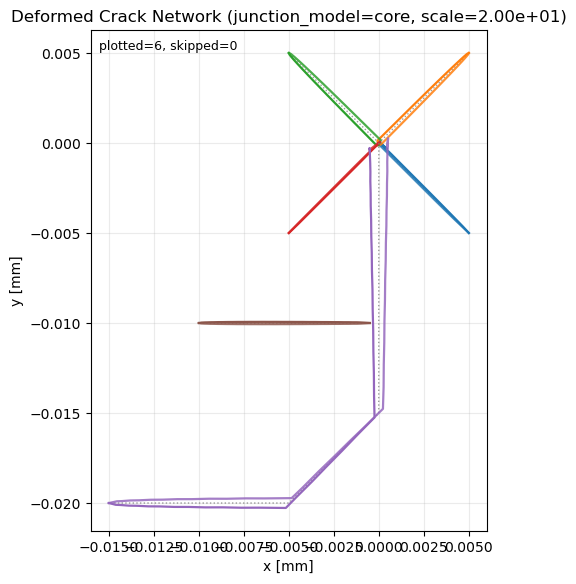

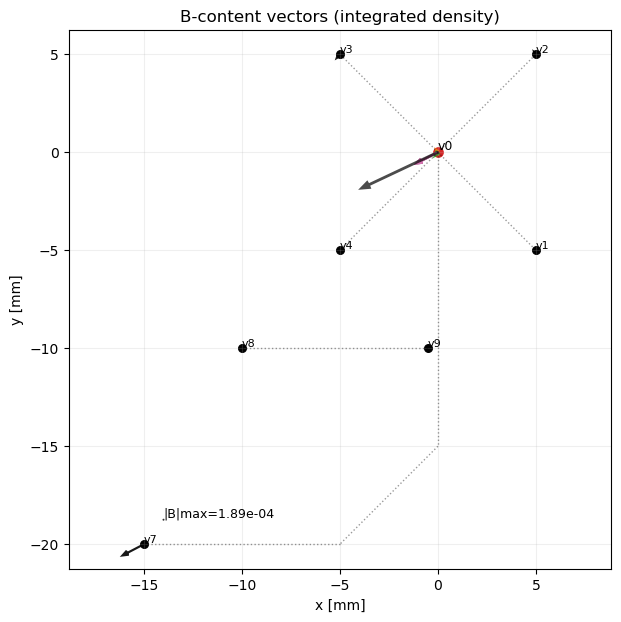

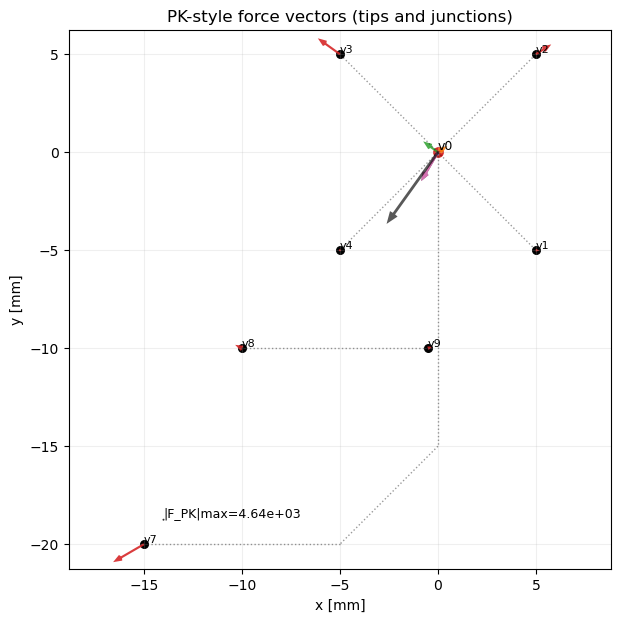

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [2]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

mm = 1e-3
vertices = np.array([
    [0,  0.0*mm,  0.0*mm],   # junction
    [1,  5.0*mm, - 5.0*mm],   # left tip
    [2, 5.0*mm,  5.0*mm],   # upper tip
    [3, -5.0*mm, 5.0*mm],
    [4, -5.0*mm, -5.0*mm], 
    [5, 0.0*mm, -15.0*mm], 
    [6, -5.0*mm, -20.0*mm],   # lower tip
    [7, -15.0*mm, -20.0*mm],   # upper tip
    [8, -10.0*mm, -10.0*mm],
    [9, -0.5*mm, -10.0*mm],
    ], dtype=float)

# Each edge: [start_node, end_node]
connectivity = [
    [0, 1],  # Edge 0: from node 0 to node 1
    [0, 2],  # Edge 1: from node 0 to node 2
    [0, 3],  # Edge 2: from node 0 to node 3
    [0, 4],  # Edge 3: from node 0 to node 4
    [0, 5],  # Edge 4: from node 0 to node 5
    [5, 6],  # Edge 5: from node 5 to node 6
    [6, 7],  # Edge 6: from node 6 to node 7
    [8, 9],  # Edge 7: from node 8 to node 9
]

generator = CrackNetworkGenerator(domain_size=(25e-3, 25e-3))
generator.load_from_arrays(vertices, connectivity)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=8, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    junction_model= "core"
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


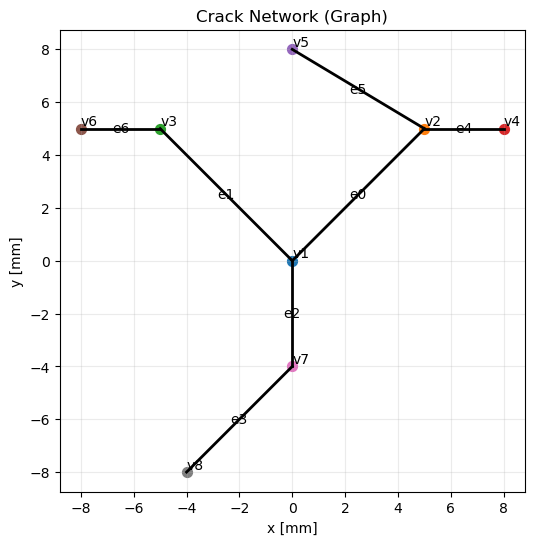

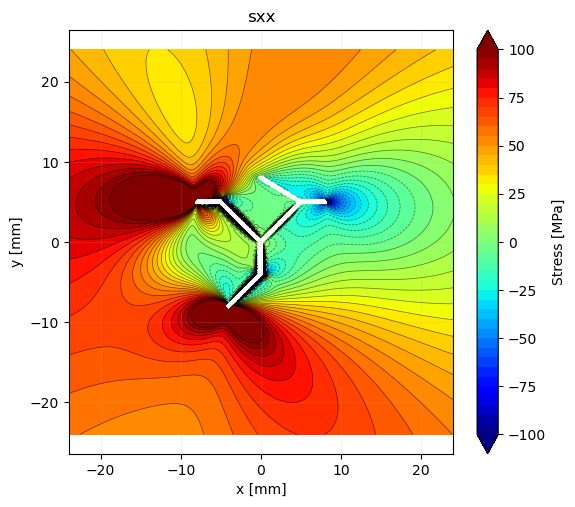

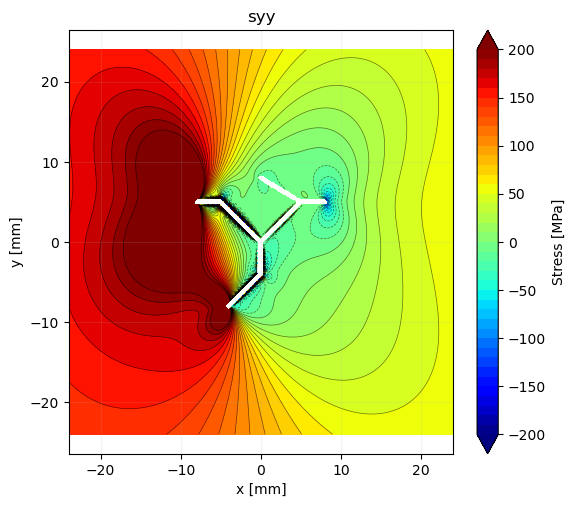

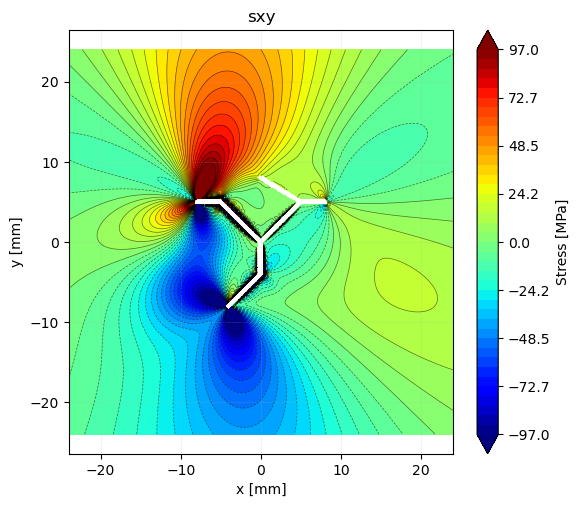

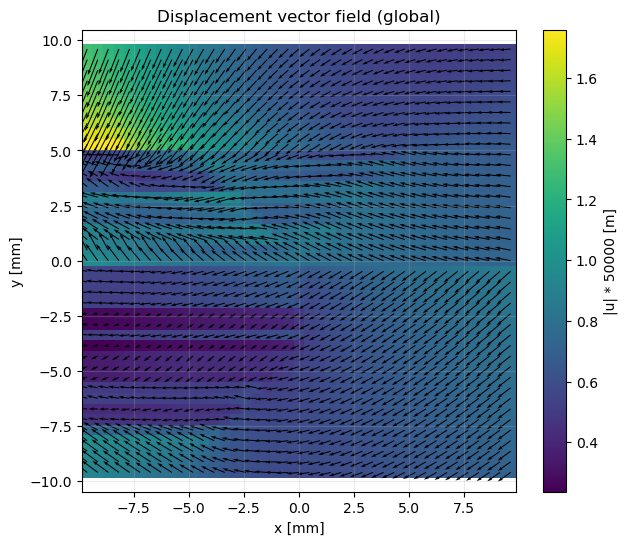

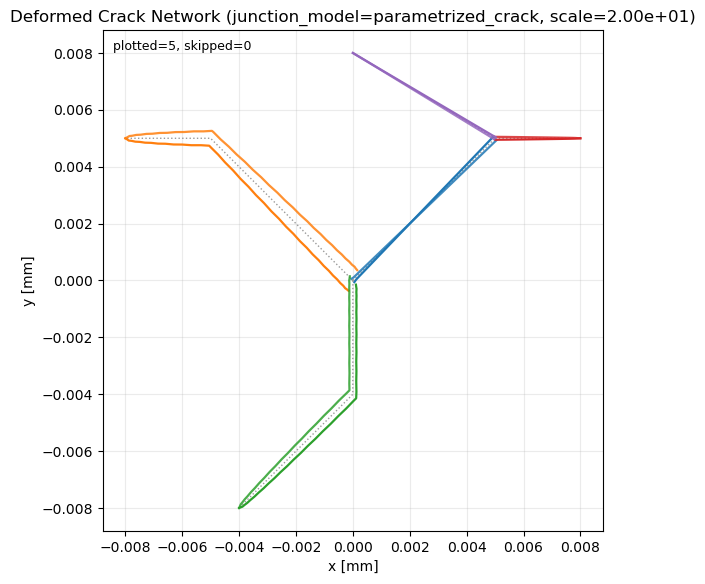

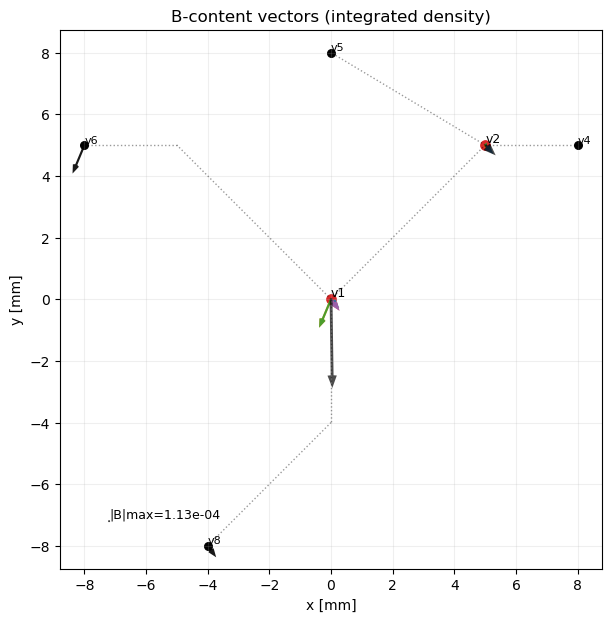

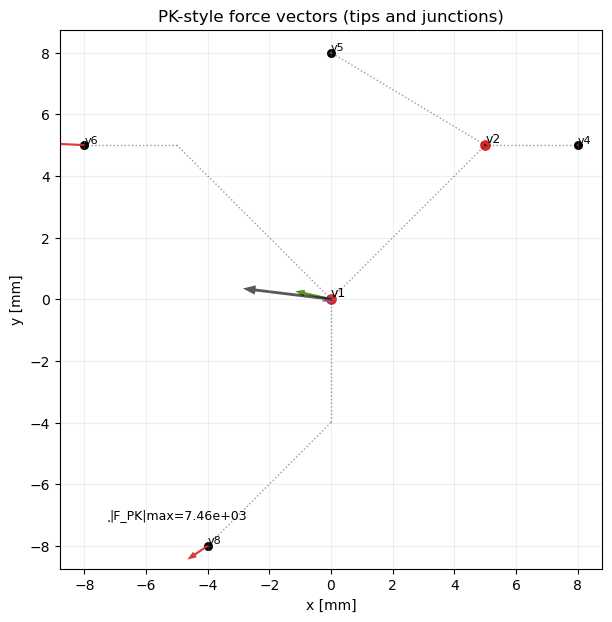

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [11]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
vertices = np.array([
    [1,  0.0*mm,  0.0*mm],
    [2,  5.0*mm,  5.0*mm],
    [3, -5.0*mm,  5.0*mm],
    [4,  8.0*mm,  5.0*mm],
    [5,  0.0*mm,  8.0*mm],
    [6, -8.0*mm,  5.0*mm],
    [7,  0.0*mm, -4.0*mm],
    [8, -4.0*mm, -8.0*mm],
], dtype=float)

connectivity = np.array([[1,2],[1,3],[1,7],[7,8],[2,4],[2,5],[3,6]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=50e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


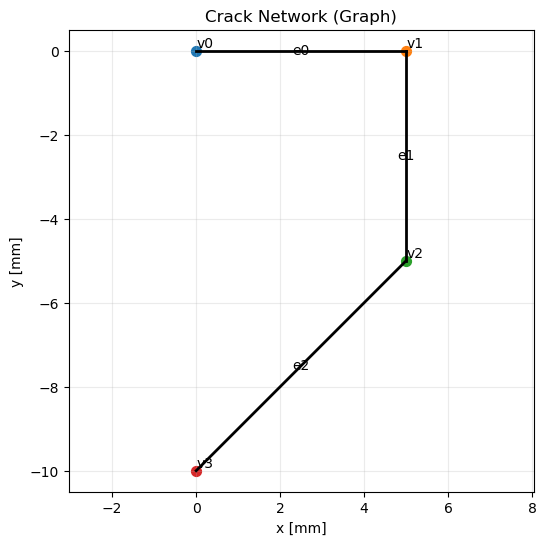

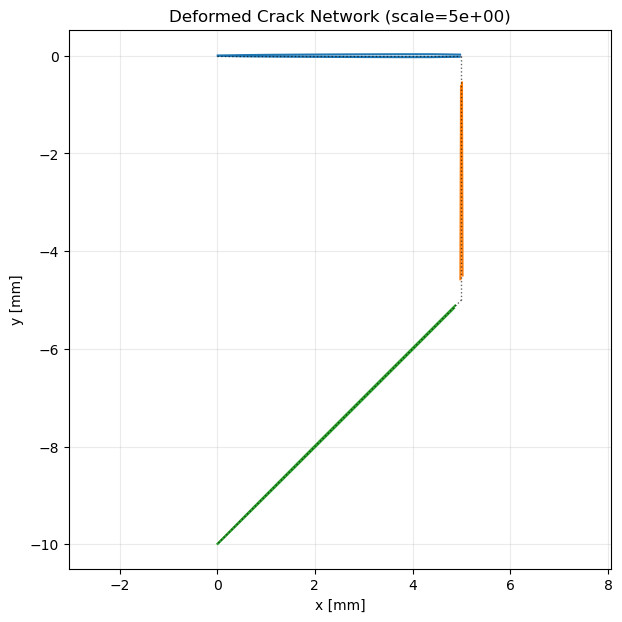

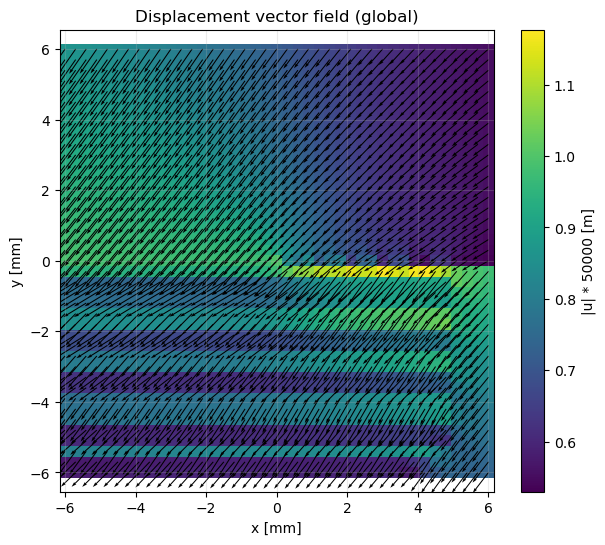

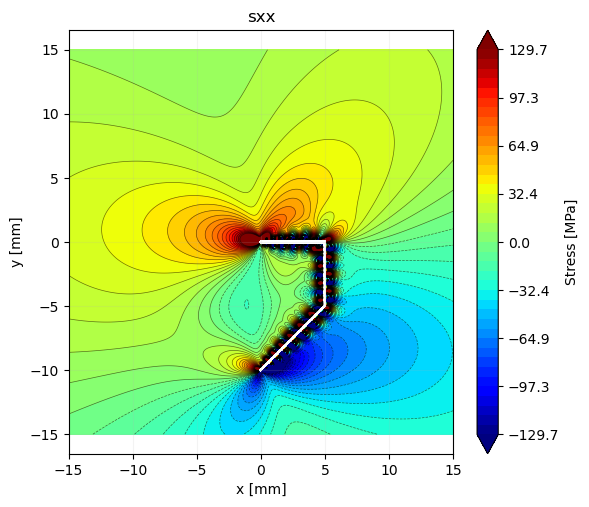

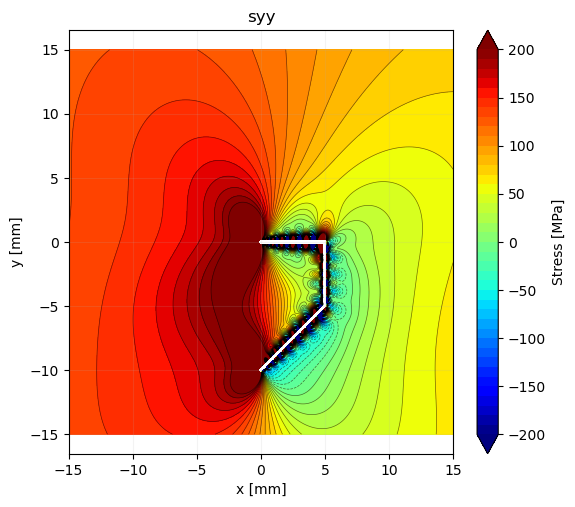

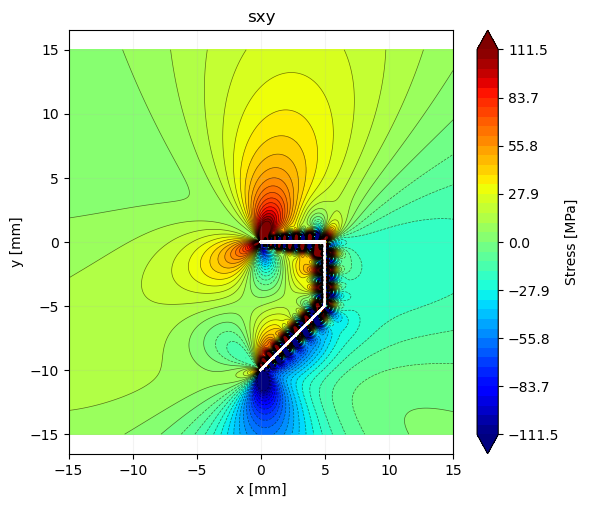

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [5]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   5.0*mm, -5.0*mm], # v2 lower-right
    [3,  0*mm,  -10.0*mm], # v3 extended lower-right
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Solve
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
    crack_mode="half"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=0.5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Generated network: 15 vertices, 6 edges

CRACK NETWORK STATISTICS
Vertices:       15
  Tips:         12
  Junctions:    0
  Internal:     3
Edges:          6
Edge lengths:
  Mean:         13.738 mm
  Std dev:      3.499 mm
  Min:          9.505 mm
  Max:          18.453 mm
Total length:   82.428 mm

EXPORTED ARRAYS

vertices =
[[0.03745401 0.09507143]
 [0.07319939 0.05986585]
 [0.01560186 0.01559945]
 [0.00580836 0.08661761]
 [0.0601115  0.07080726]
 [0.00205845 0.09699099]
 [0.08324426 0.02123391]
 [0.0181825  0.01834045]
 [0.03042422 0.05247564]
 [0.0431945  0.02912291]
 [0.06118529 0.01394939]
 [0.02921446 0.03663618]
 [0.045607   0.0785176 ]
 [0.01996738 0.05142344]
 [0.05924146 0.00464504]]

connectivity =
[[ 0 12]
 [ 1  4]
 [ 3  5]
 [ 8 13]
 [ 9 11]
 [10 14]]

vertex_types =
['tip', 'tip', 'internal', 'tip', 'tip', 'tip', 'internal', 'internal', 'tip', 'tip', 'tip', 'tip', 'tip', 'tip', 'tip

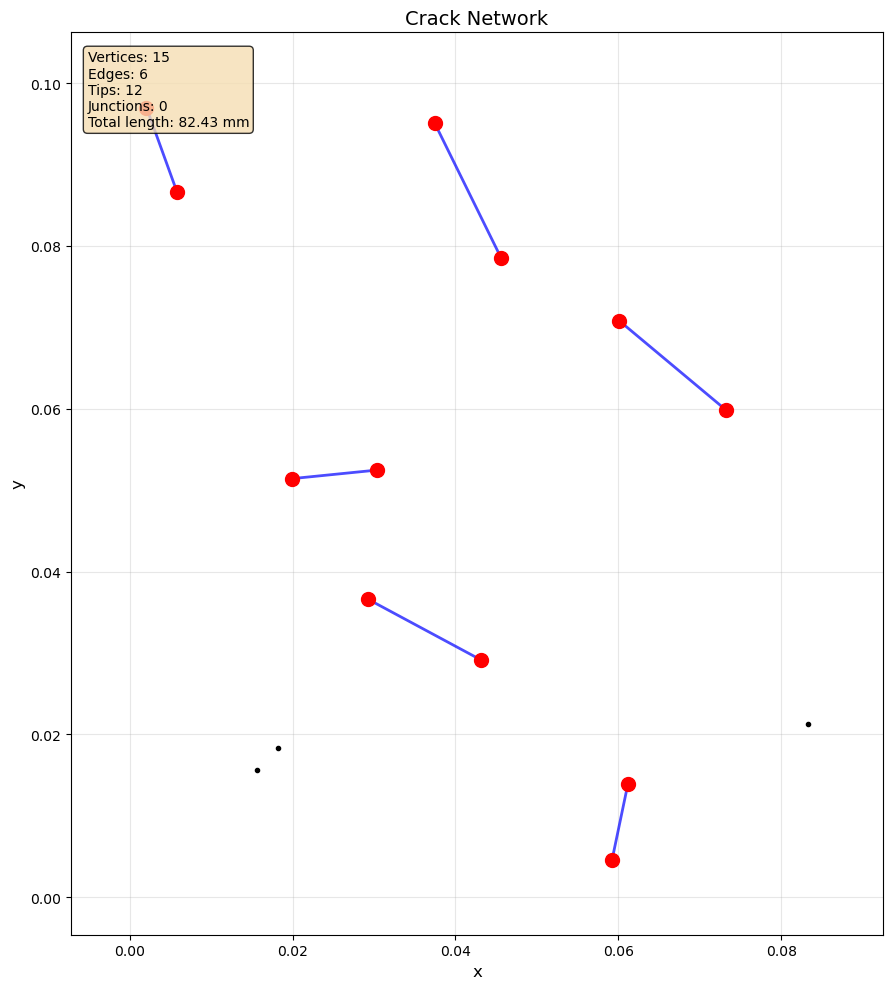

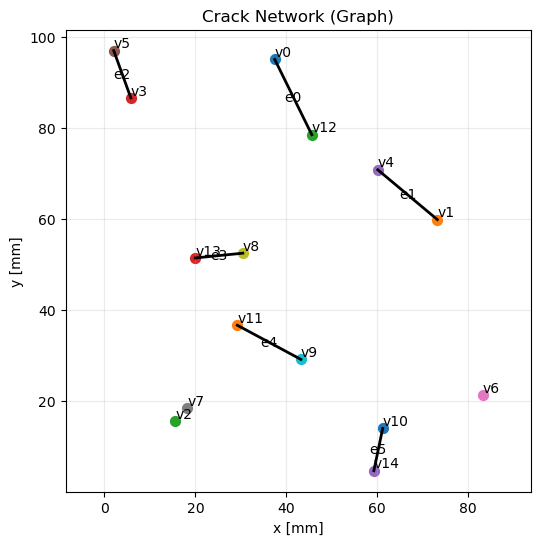

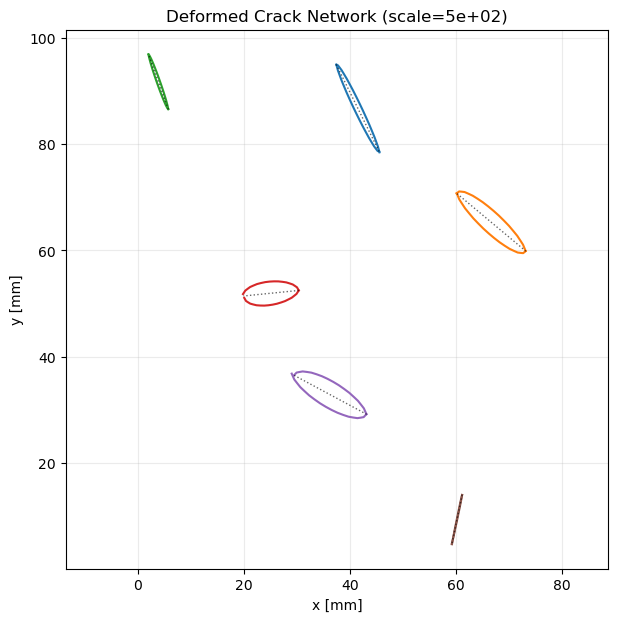

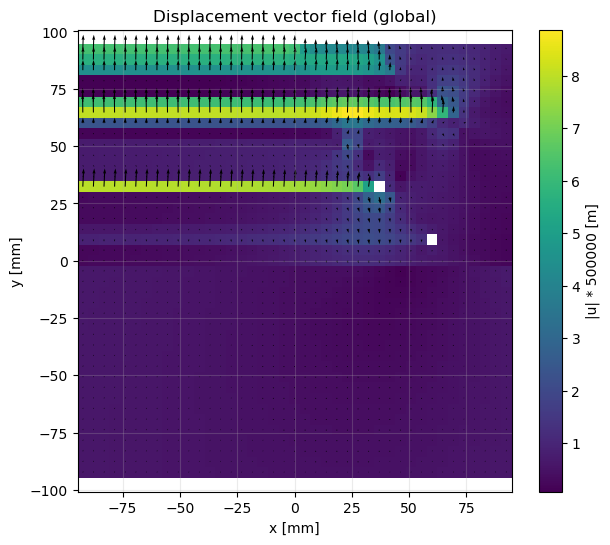

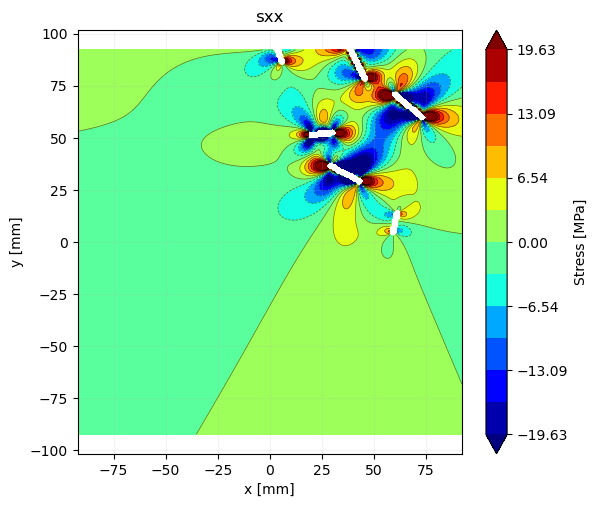

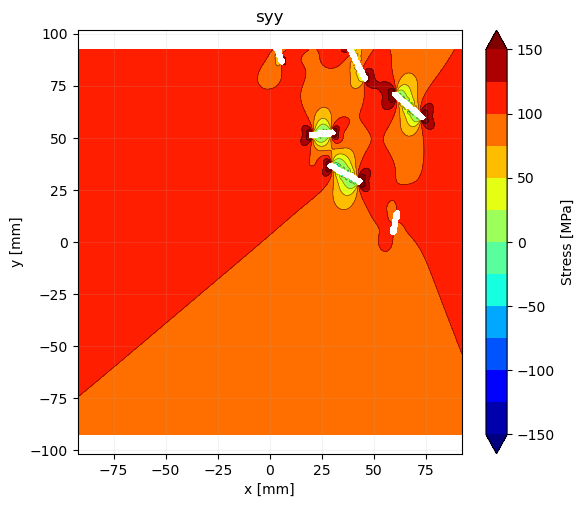

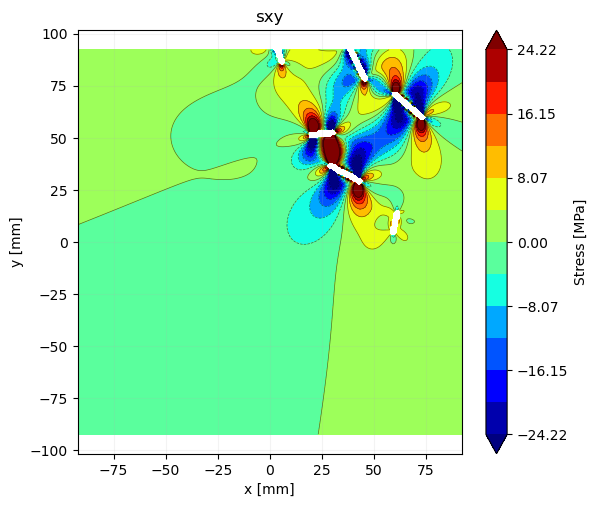

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2


In [6]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()


mm = 1e-3
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2")
out_dir.mkdir(parents=True, exist_ok=True)

generator = CrackNetworkGenerator(
    domain_size=(100*mm, 100*mm),
    seed=42,
)


# Generate network
generator.generate_network(
    n_junctions=0,           # Number of junction vertices
    n_tips=15,                # Number of tip vertices
    edge_length_mean=40*mm,   # Mean edge length
    edge_length_std=5*mm,    # Std dev of edge length
    max_junction_order=3,    # Max junction degree (3-4 typical)
    spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
    connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
    min_edge_length=5*mm,
    max_edge_length=20*mm
)

# Print statistics
generator.print_statistics()

# Visualize
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=10,
    edge_color='blue',
    edge_width=2.0
)
# plt.show()

# Export to your format
vertices, connectivity, vertex_types = generator.to_arrays()

print("\n" + "="*60)
print("EXPORTED ARRAYS")
print("="*60)
print("\nvertices =")
print(vertices)
print("\nconnectivity =")
print(connectivity)
print("\nvertex_types =")
print(vertex_types)

# Use with your CrackNetworkV4
net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material=material, network=net, applied=applied)

sol = calc.solve(
    ne_half=10,                   # start here
    representation="cheb_quad",   # keep cheb_quad and cheb_spectral available
    node_distribution="tip_dense",
    crack_mode="half",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# -------------------------
# Network-level plots
# -------------------------
plotter.plot_network_graph()
plotter.plot_deformed_network(scale=5e2, n_pts_per_edge=1000)  # scale in plot title

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e5,       # <--- magnify displacements for visibility
)

# Stress fields (global) with bands/contours
opts = StressPlotOptsV4(
    extent_factor=2,
    n_grid=251,
    add_remote=True,
    vmax_factor=1.5,     # cap at 10x remote component (MPa basis)
    cmap="jet",
    n_bands=12,
    label_contours=False,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Generated network: 20 vertices, 15 edges

CRACK NETWORK STATISTICS
Vertices:       20
  Tips:         12
  Junctions:    2
  Internal:     6
Edges:          15
Edge lengths:
  Mean:         2.875 mm
  Std dev:      1.704 mm
  Min:          0.669 mm
  Max:          6.447 mm
Total length:   43.126 mm


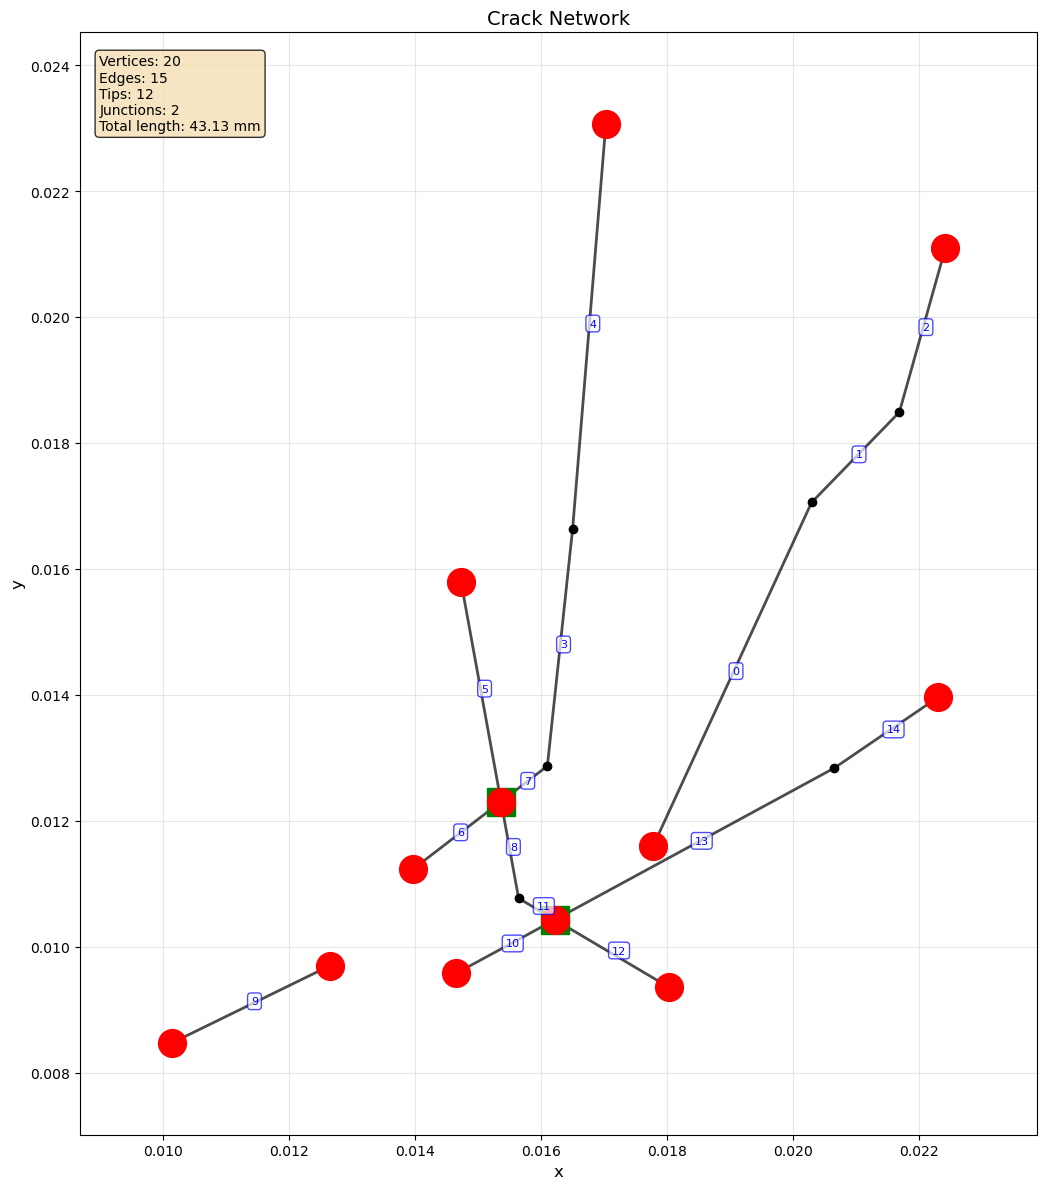

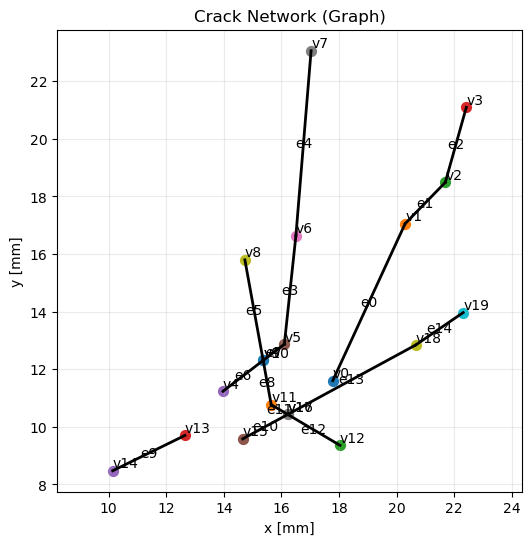

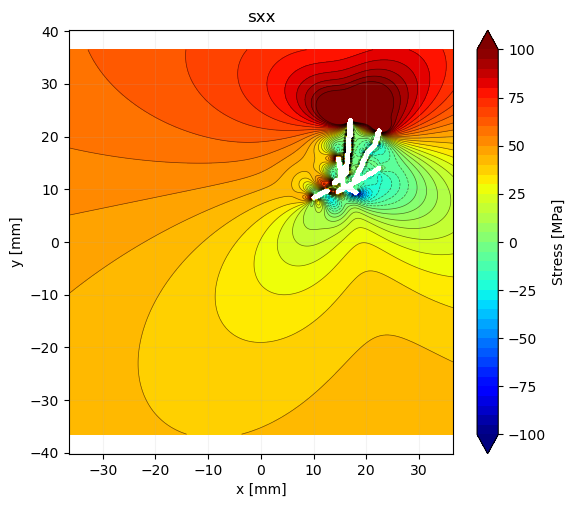

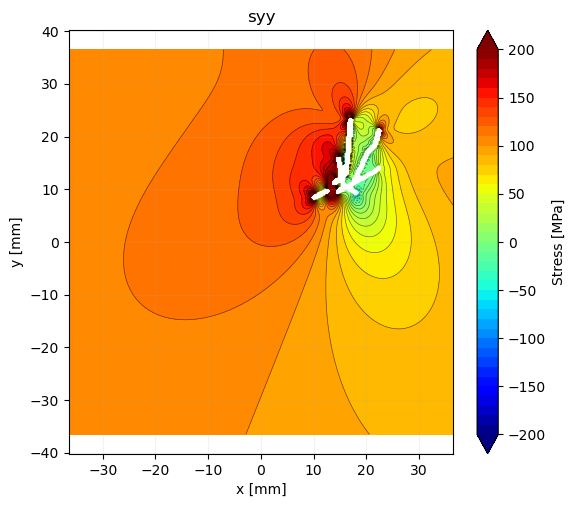

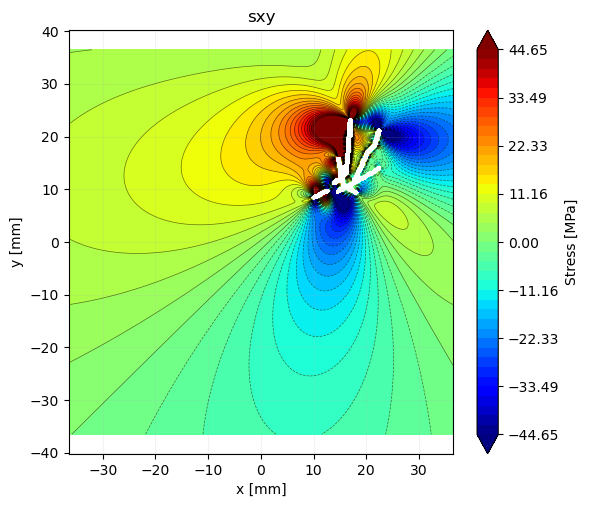

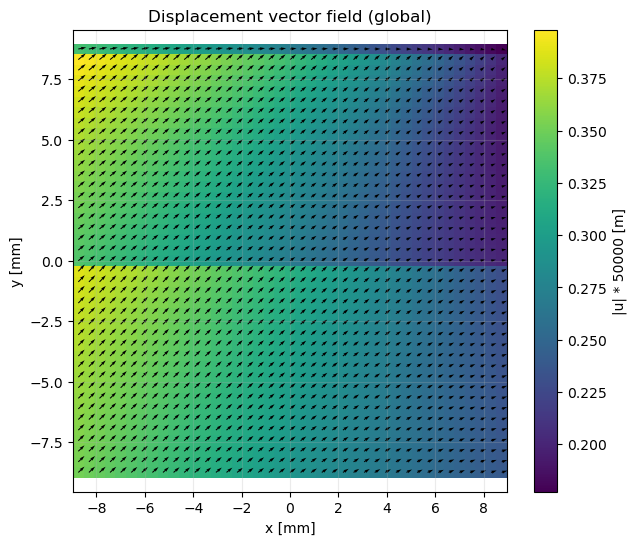

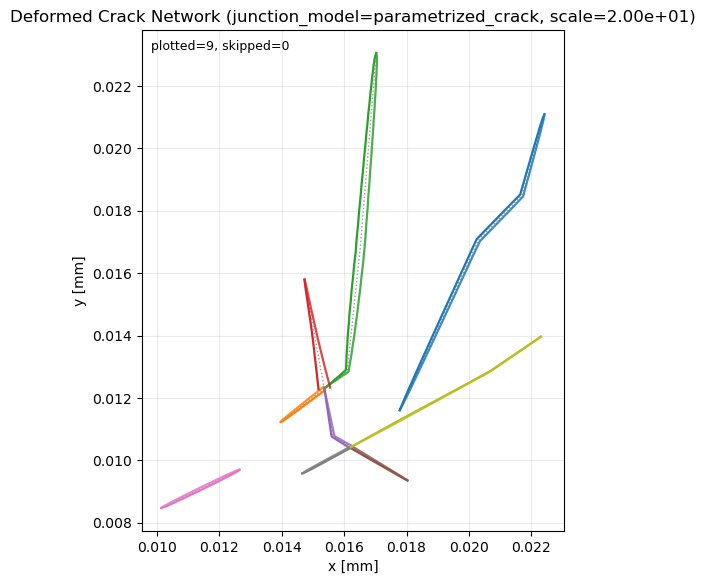

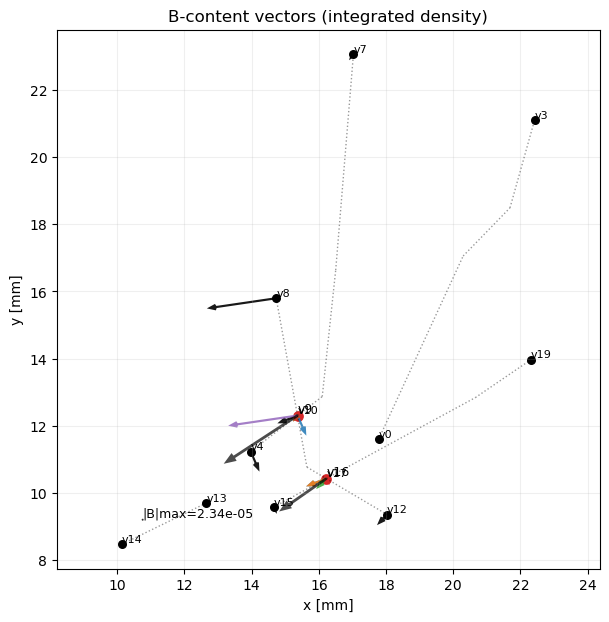

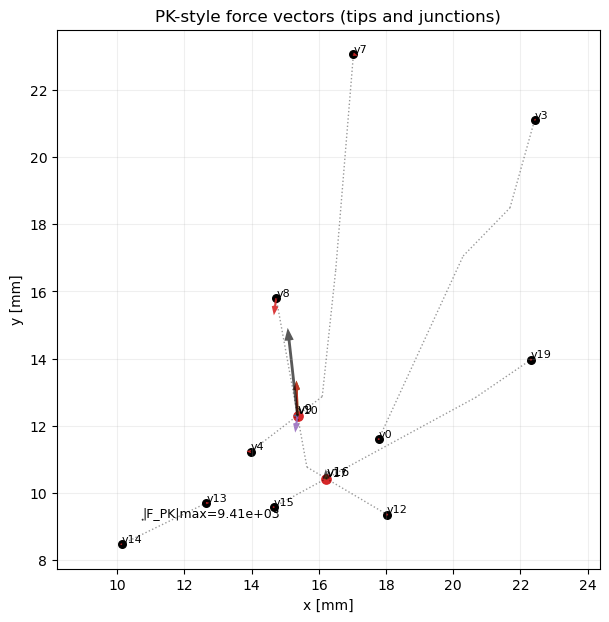

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [22]:

from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
# Generate exactly 3 non-intersecting meandering cracks, each with 3 edges
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=4  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=4,
    n_tips=10,
    
    # Edge properties for meandering
    edge_length_mean=5*mm,
    edge_length_std=2*mm,
    min_edge_length=2*mm,
    max_edge_length=10*mm,
    
    # Exactly 3 cracks, each with 3 segments
    n_crack_paths=5,
    segments_per_path_mean=4,
    segments_per_path_std=2,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=30.0,     # Small random angles (±30°)
    
    # Non-intersecting
    allow_intersections=True,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='clustered'
)


# Print statistics
generator.print_statistics()

# Visualize with path coloring to see the 3 separate cracks
fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=20,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity, vertex_types = generator.to_arrays()

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=50e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=5,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


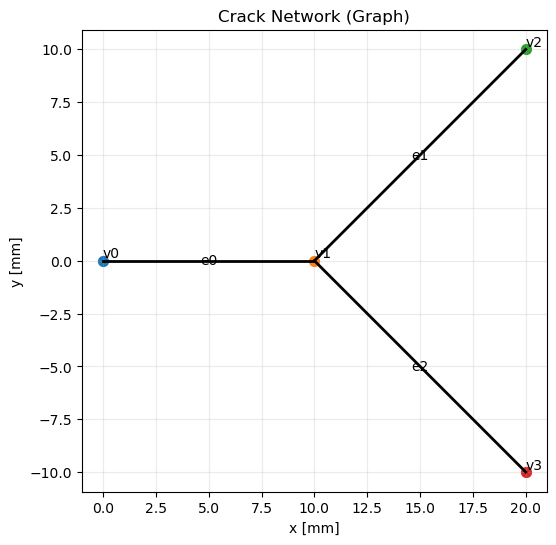

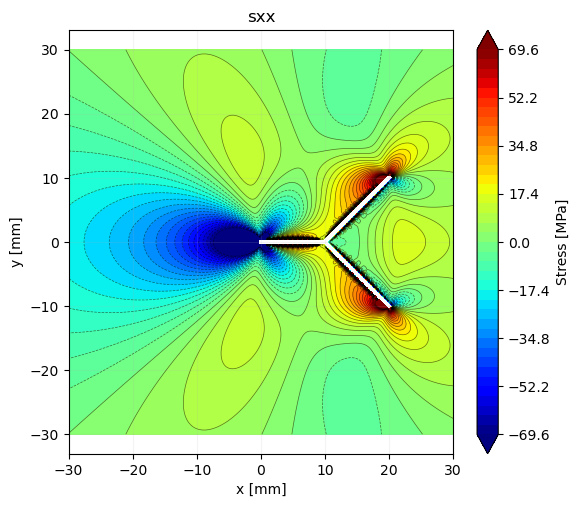

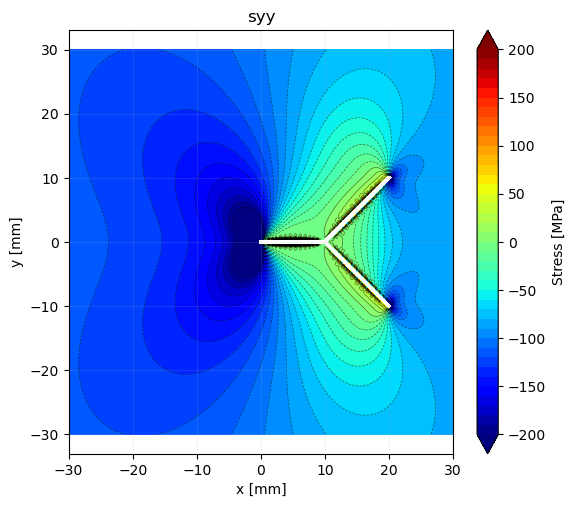

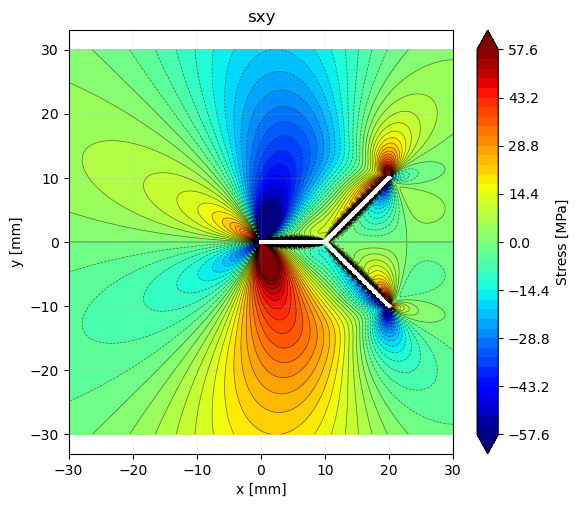

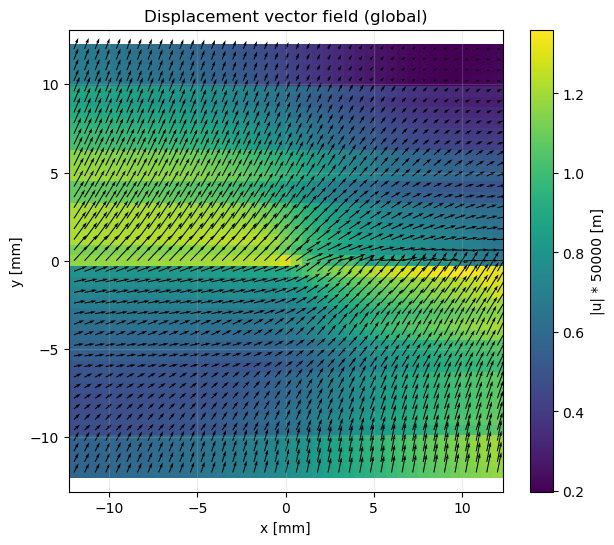

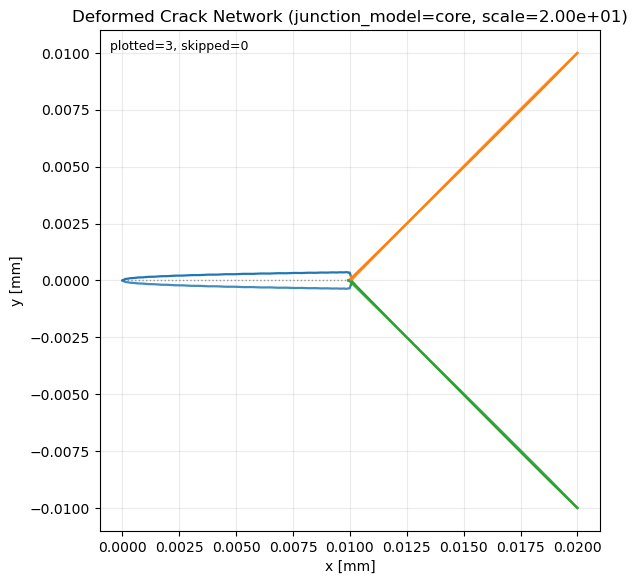

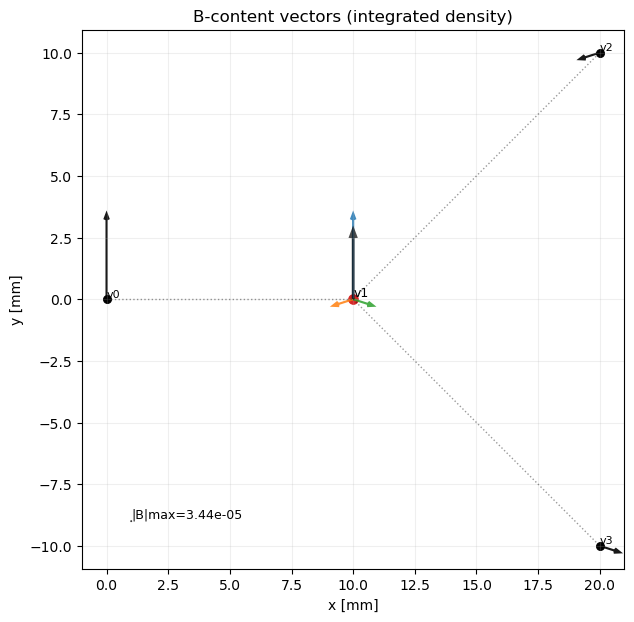

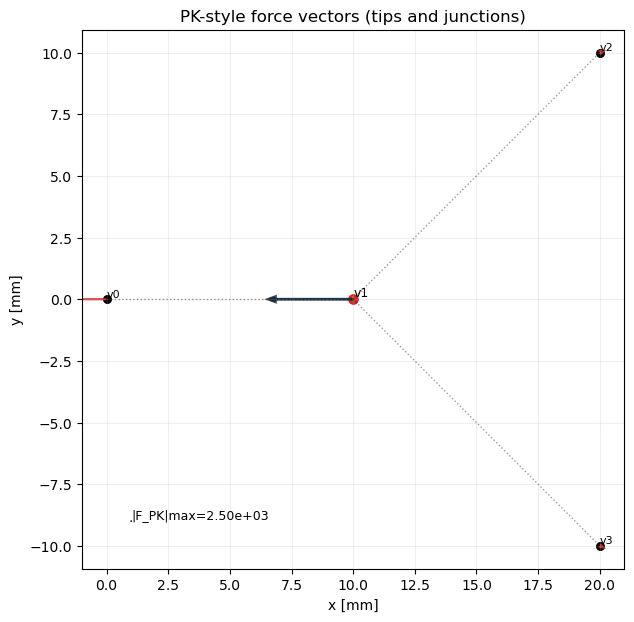

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [3]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  10.0*mm,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  20.0*mm,  10*mm],   # v2 (right end)
    [3,  20.0*mm,  -10*mm],   # v3 (extra vertex, not used)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [1, 3]
], dtype=int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=-100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


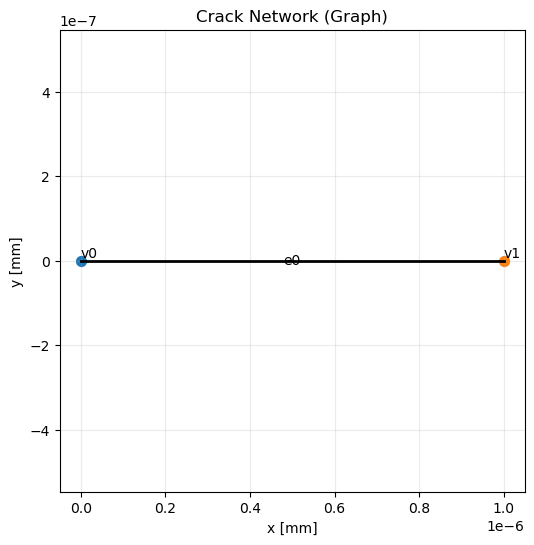

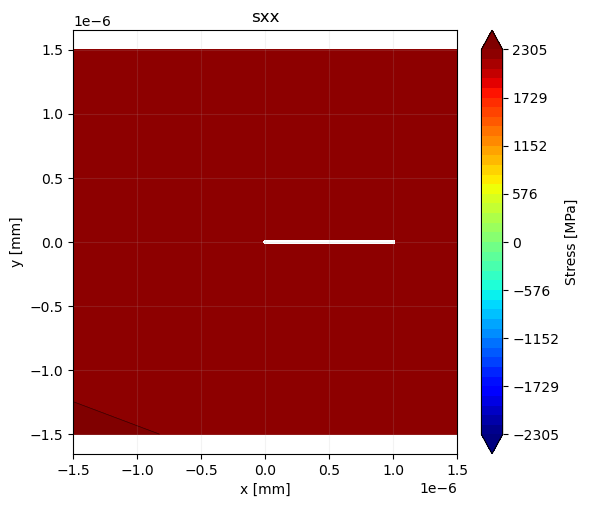

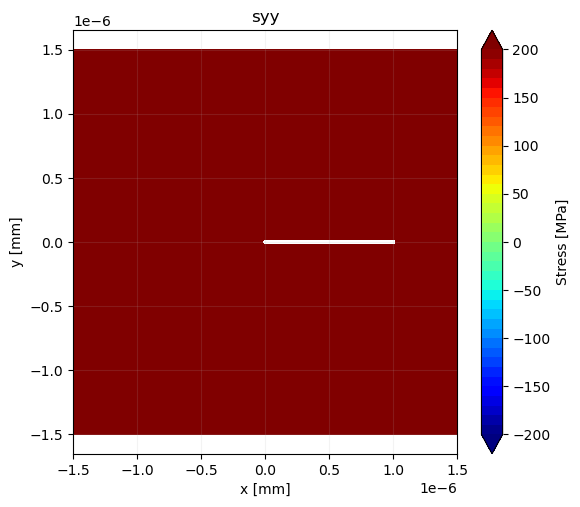

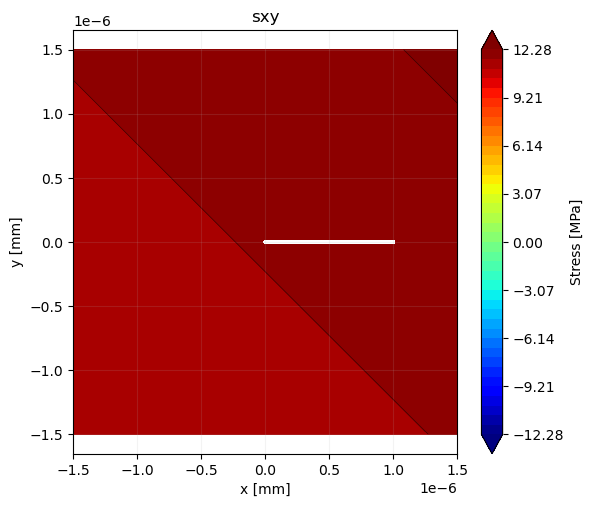

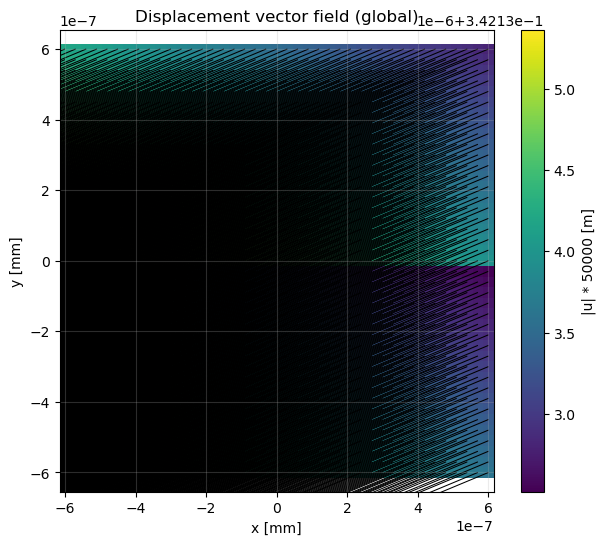

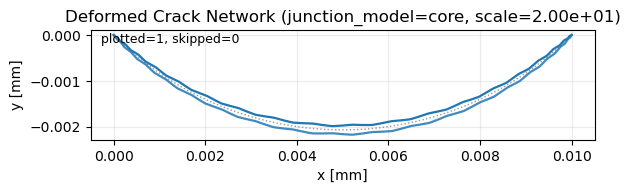

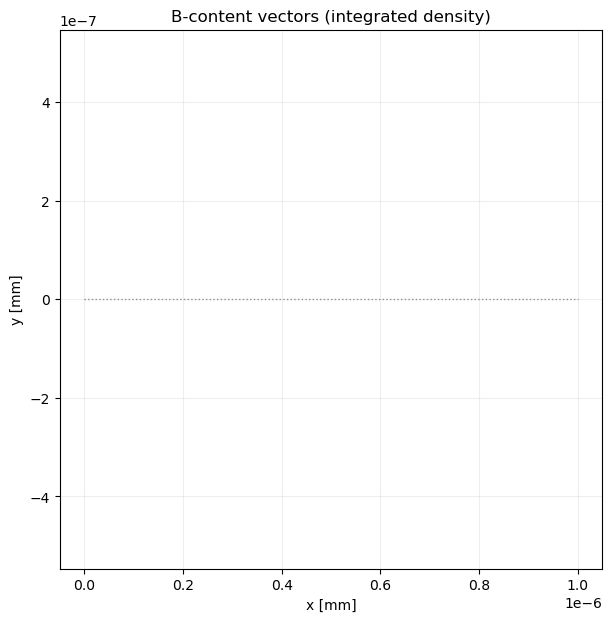

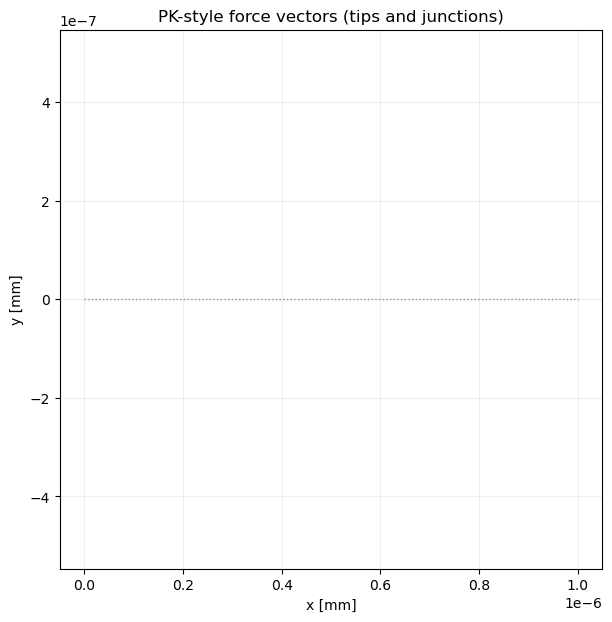

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [7]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3

vertices = np.array([
    [0, 0.0,     0.0],
    [1, 1e-6*mm, 0.0],   # tiny but not identical
], dtype=float)

connectivity = np.array([[0, 1]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

arc_branches = [
    dict(p0=[0.0, 0.0], p1=[10.0*mm, 0.0], center=[5*mm, 5*mm], ccw=True),
]
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    parametrization="arc",
    arc_branches=arc_branches,
    node_distribution="tip_dense",
    nq_col=3,
    nq_stress=6,
    junction_model="core",
)


res = DCEResultsNetworkV4(calc, sol)


# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)
